# CatchFish — Real-World Phishing Detection Pipeline (Google Colab)

**What this notebook does:**
- Automatically discovers **all CSV files** in the `dataset/` folder
- Handles two schemas automatically (original datasets + pre-processed format)
- Trains 5 classifiers and selects the best by F1 at threshold 0.60
- Saves `phishing_detection.pkl` ready for `app.py`

**To add more data:** just drop any CSV into `dataset/` before running — no code changes needed.

Supported label formats: `0/1` (int) or `phishing`/`legitimate`/`spam`/`ham` (text)
Supported schemas:
- **Schema A** (original): columns `sender, body, subject, label`
- **Schema B** (pre-processed): columns `email_text, subject, sender_domain, has_attachment, links_count, urgent_keywords, label`


In [19]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 — Setup: Local Runtime (No Drive Needed)
# ════════════════════════════════════════════════════════════════════════════

# Since dataset/ is already uploaded in Colab runtime, no need to mount Drive

import os

# Correct path (relative to Colab working directory)
DATASET_PATH = '/content/dataset'

# Verify folder exists
assert os.path.isdir(DATASET_PATH), f'Dataset folder not found: {DATASET_PATH}'

print('✓ Dataset folder found. Files inside:')
for f in sorted(os.listdir(DATASET_PATH)):
    print(f'  {f}')

In [20]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 — Install packages (XGBoost already in Colab, just confirming)
# ════════════════════════════════════════════════════════════════════════════
!pip install -q xgboost
print('✓ Packages ready')

✓ Packages ready


In [21]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 — Imports & Reference Data (embedded — no JSON files needed)
# ════════════════════════════════════════════════════════════════════════════
import re, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              roc_curve, precision_recall_curve, average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.preprocessing import StandardScaler
import joblib

# ── Reference data embedded directly (from datasets/*.json) ──────────────────
LEGITIMATE_DOMAINS = set(["gmail.com","yahoo.com","outlook.com","hotmail.com","live.com",
    "microsoft.com","apple.com","amazon.com","google.com","facebook.com","linkedin.com",
    "twitter.com","github.com","stackoverflow.com","office365.com","office.com",
    "onedrive.com","icloud.com","protonmail.com","zoho.com","company.com","colleague.com",
    "client.com","partner.com","local.com","dropbox.com","slack.com","zoom.us",
    "adobe.com","salesforce.com","netflix.com","spotify.com","youtube.com",
    "instagram.com","whatsapp.com","telegram.org","paypal.com","stripe.com",
    "aws.amazon.com","azure.microsoft.com","cloud.google.com","shopify.com",
    "wordpress.com","hubspot.com","mailchimp.com","sendgrid.com","twilio.com",
    "cloudflare.com","godaddy.com","namecheap.com","bluehost.com","hostgator.com",
    "siteground.com","edu.np","gov.np","edu","gov","ac.uk","gov.uk",
    "rediff.com","aol.com","mail.com","ymail.com","me.com","mac.com","googlemail.com"])

SUSPICIOUS_TLDS = set([".xyz",".tk",".ml",".ga",".cf",".gq",".top",".loan",".online",
    ".site",".click",".link",".bid",".win",".stream",".review",".party",".download",
    ".racing",".date",".faith",".science",".trade",".work",".info",".biz",".buzz",
    ".mobi",".name",".pw",".cc",".ws",".su",".nu",".club",".space",".website",
    ".press",".guru",".rocks",".ninja",".tools",".accountant",".cricket",".men",
    ".webcam",".gdn",".icu",".rest",".vip",".ltd",".email",".solutions",".zone",
    ".world",".today",".live",".run",".fun"])

URL_SHORTENERS = set(["bit.ly","tinyurl.com","goo.gl","ow.ly","t.co","is.gd","buff.ly",
    "shorte.st","adf.ly","short.io","tiny.cc","cutt.ly","rb.gy","shorturl.at",
    "tinycc.com","bl.ink","snip.ly","clck.ru","qps.ru","u.to","v.gd","x.co",
    "cli.gs","ff.im","su.pr","tr.im","twurl.nl","ur1.ca","3.ly","7.ly",
    "alturl.com","b2l.me","budurl.com","doiop.com","easyurl.net","fff.to",
    "go2l.ink","golinks.io","href.li","j.mp","kissa.be","lnkd.in","mcaf.ee",
    "migre.me","moourl.com","notlong.com","ping.fm","post.ly","qr.cx","redir.ec",
    "retwt.me","s.id","scrnch.me","smarturl.it","snurl.com","soo.gd","spedr.com",
    "starturl.com","tiny.pl","to.ly","urlcut.com","urlex.org","urlhawk.com",
    "whrt.it","yourls.org","zi.ma"])

URGENT_KEYWORDS = ['urgent','immediate','action required','verify','suspended',
    'click now','confirm','account','password','login','update',
    'alert','security','limited time','expire','expires']

THRESHOLD = 0.60
NUMERIC_FEATURES = [
    'has_attachment','links_count','urgent_keywords',
    'email_length','subject_length','link_density',
    'domain_age','special_chars','html_tags',
    'legitimate_domain','suspicious_tld',
    'ip_url_count','shortener_url_count',
    'https_url_count','http_url_count','http_ratio',
    'domain_length','domain_has_digits','domain_has_hyphen',
]

print('✓ Imports complete')
print(f'  Legitimate domains : {len(LEGITIMATE_DOMAINS)}')
print(f'  Suspicious TLDs    : {len(SUSPICIOUS_TLDS)}')
print(f'  URL shorteners     : {len(URL_SHORTENERS)}')

✓ Imports complete
  Legitimate domains : 66
  Suspicious TLDs    : 59
  URL shorteners     : 66


---
## STEP 1 — Original Dataset Column Analysis

In [22]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 — Inspect every CSV in dataset/ (auto-discovered)
# ════════════════════════════════════════════════════════════════════════════

import os
import pandas as pd

# Auto-discover all CSV files — no hardcoding needed
import re as _re
_SYNTHETIC_RE = _re.compile(r"^dataset\d+\.csv$", _re.IGNORECASE)
ALL_CSV_FILES = sorted(
    f for f in os.listdir(DATASET_PATH)
    if f.lower().endswith(".csv") and not _SYNTHETIC_RE.match(f)
)
print(f"Found {len(ALL_CSV_FILES)} CSV file(s): " + " ".join(ALL_CSV_FILES))
print()

raw_summary = []

for fname in ALL_CSV_FILES:
    path = os.path.join(DATASET_PATH, fname)
    try:
        df_raw = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
        df_raw.columns = df_raw.columns.str.strip().str.strip('"').str.lower()

        schema = "B (pre-processed)" if "email_text" in df_raw.columns else "A (original)"

        label_counts = df_raw["label"].value_counts().to_dict() if "label" in df_raw.columns else {}

        raw_summary.append({
            "File"         : fname,
            "Rows"         : len(df_raw),
            "Schema"       : schema,
            "Columns"      : ", ".join(df_raw.columns.tolist()),
            "Label values" : str(label_counts),
        })

        print(f"FILE : {fname}  |  Schema: {schema}")
        print(f"  Shape : {df_raw.shape}")
        print(f"  Cols  : {df_raw.columns.tolist()}")
        print(f"  Label : {label_counts}")
        print()

    except Exception as e:
        print(f"FILE : {fname}  →  ERROR: {e}")

display(pd.DataFrame(raw_summary))

---
## STEP 2 — Column Mapping & Derived Feature Explanation

In [23]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 — Column mapping table
# ════════════════════════════════════════════════════════════════════════════
mapping = pd.DataFrame([
    {'Required Field':'email_text',       'Source':'body column','Derivation':'HTML clean + whitespace normalise'},
    {'Required Field':'subject',          'Source':'subject column','Derivation':'clean whitespace'},
    {'Required Field':'sender_domain',    'Source':'sender column (if present)','Derivation':'regex extract domain from email address; empty string if no sender col'},
    {'Required Field':'has_attachment',   'Source':'NOT available in any dataset','Derivation':'default = 0'},
    {'Required Field':'links_count',      'Source':'derived from email_text','Derivation':'count URLs via regex https?://[^\\s]+'},
    {'Required Field':'urgent_keywords',  'Source':'derived from subject+body','Derivation':'count occurrences of 16 urgency keywords'},
    {'Required Field':'label',            'Source':'label column','Derivation':'already 0/1 in all 6 files (1=phishing, 0=legitimate)'},
])
display(mapping)

print('''
DATASETS WITH sender column : Nazario, Nigerian_Fraud, SpamAssasin
DATASETS WITHOUT sender     : Enron, Ling  →  sender_domain = ""

All datasets use integer labels already:
  1 = phishing/spam
  0 = legitimate/ham
No label conversion needed.
Synthetic datasetN.csv files are automatically excluded.
''')

---
## STEP 3 — Data Cleaning & Dataset Construction  *(DATASET REPLACEMENT STEP)*

In [24]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 — Cleaning helpers + Universal CSV loader
# ════════════════════════════════════════════════════════════════════════════

import re
import pandas as pd

# Regex patterns
HTML_TAG_RE = re.compile(r"<[^>]+>")
MULTI_WS_RE = re.compile(r"[ \t]+")
URL_RE      = re.compile(r"https?://[^\s]+", re.IGNORECASE)
SENDER_RE   = re.compile(r"[\w.\-+]+@([\w.\-]+\.\w{2,})")

# Example urgent keywords (edit if needed)
URGENT_KEYWORDS = [
    "urgent", "immediate", "action required", "verify",
    "account suspended", "click now", "limited time", "asap"
]

# Label normalisation — covers int and text variants
LABEL_MAP = {
    "1": 1, "phishing": 1, "spam": 1, "malicious": 1,
    "0": 0, "legitimate": 0, "ham": 0, "safe": 0, "benign": 0,
}

# ───────────────────────────────────────────────────────────────────────────

def clean_text(text):
    """Clean email text safely."""
    if not isinstance(text, str):
        text = "" if pd.isna(text) else str(text)

    text = HTML_TAG_RE.sub(" ", text)
    text = URL_RE.sub(" URL ", text)  # normalize URLs
    text = text.replace('\r', ' ').replace('\n', ' ')

    return MULTI_WS_RE.sub(" ", text).strip()

# ───────────────────────────────────────────────────────────────────────────

def extract_domain(sender):
    """Extract domain from sender email."""
    if not isinstance(sender, str) or not sender.strip():
        return ""

    m = SENDER_RE.search(sender)
    if m:
        return m.group(1).lower().strip(".")

    if "@" in sender:
        return sender.split("@", 1)[1].strip().lower().rstrip(">")

    return ""

# ───────────────────────────────────────────────────────────────────────────

def count_links(text):
    """Count number of URLs in text."""
    return len(URL_RE.findall(str(text)))

# ───────────────────────────────────────────────────────────────────────────

def count_urgent(subject, body):
    """Count urgent keywords in subject + body."""
    combined = (str(subject) + " " + str(body)).lower()
    return sum(1 for kw in URGENT_KEYWORDS if kw in combined)

# ───────────────────────────────────────────────────────────────────────────

def to_numeric_col(series):
    """Strip quotes and coerce to int, default 0."""
    return (
        pd.to_numeric(
            series.astype(str)
                  .str.strip()
                  .str.strip('"')
                  .str.strip("'"),
            errors="coerce",
        ).fillna(0).astype(int)
    )

# ───────────────────────────────────────────────────────────────────────────

def load_any_csv(fpath):
    """
    Universal loader — auto-detects schema and normalises to:
      label (0/1), email_text, subject, sender_domain,
      has_attachment, links_count, urgent_keywords

    Supported schemas:
    A: body, sender, subject, label
    B: email_text, sender_domain, has_attachment,
       links_count, urgent_keywords, label
    """

    raw = pd.read_csv(fpath, encoding="utf-8", on_bad_lines="skip")

    # Clean column names
    raw.columns = (
        raw.columns
        .str.strip()
        .str.strip('"')
        .str.strip("'")
        .str.lower()
    )

    out = pd.DataFrame()

    # ── Label → int 0/1 ─────────────────────────────────────────────────────
    if "label" in raw.columns:
        lbl = (
            raw["label"]
            .astype(str)
            .str.strip()
            .str.strip('"')
            .str.strip("'")
            .str.lower()
        )
        out["label"] = lbl.map(LABEL_MAP).fillna(0).astype(int)
    else:
        out["label"] = 0

    # ── Email text ──────────────────────────────────────────────────────────
    if "email_text" in raw.columns:
        out["email_text"] = raw["email_text"].fillna("").apply(clean_text)
    elif "body" in raw.columns:
        out["email_text"] = raw["body"].fillna("").apply(clean_text)
    else:
        out["email_text"] = ""

    # ── Subject ─────────────────────────────────────────────────────────────
    if "subject" in raw.columns:
        out["subject"] = raw["subject"].fillna("").apply(clean_text)
    else:
        out["subject"] = ""

    # ── Sender domain ───────────────────────────────────────────────────────
    if "sender_domain" in raw.columns:
        out["sender_domain"] = (
            raw["sender_domain"]
            .astype(str)
            .str.strip()
            .str.strip('"')
            .fillna("")
        )
    elif "sender" in raw.columns:
        out["sender_domain"] = raw["sender"].fillna("").apply(extract_domain)
    else:
        out["sender_domain"] = ""

    # ── has_attachment ──────────────────────────────────────────────────────
    if "has_attachment" in raw.columns:
        out["has_attachment"] = to_numeric_col(raw["has_attachment"])
    else:
        out["has_attachment"] = 0

    # ── links_count ─────────────────────────────────────────────────────────
    if "links_count" in raw.columns:
        out["links_count"] = to_numeric_col(raw["links_count"])
    else:
        out["links_count"] = out["email_text"].apply(count_links)

    # ── urgent_keywords ─────────────────────────────────────────────────────
    if "urgent_keywords" in raw.columns:
        out["urgent_keywords"] = to_numeric_col(raw["urgent_keywords"])
    else:
        out["urgent_keywords"] = out.apply(
            lambda r: count_urgent(r["subject"], r["email_text"]),
            axis=1
        )

    return out

# ───────────────────────────────────────────────────────────────────────────

print("✓ Universal loader ready")

✓ Universal loader ready


In [25]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 — Load, normalise and merge ALL datasets (auto-discovered)
# ════════════════════════════════════════════════════════════════════════════

import os
import pandas as pd

print(f"Loading {len(ALL_CSV_FILES)} CSV file(s) from dataset/ ...\n")

parts = []

for fname in ALL_CSV_FILES:
    fpath = os.path.join(DATASET_PATH, fname)
    try:
        part = load_any_csv(fpath)

        ph = int((part["label"] == 1).sum())
        lg = int((part["label"] == 0).sum())

        print(f"  {fname:30s} → {len(part):7,} rows  phishing={ph:,}  legitimate={lg:,}")
        parts.append(part)

    except Exception as e:
        print(f"  {fname:30s} → SKIPPED ({e})")

# ── Merge all parts ─────────────────────────────────────────────────────────
df = pd.concat(parts, ignore_index=True)

# ── Remove duplicates ──────────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=["email_text", "subject"])

print(f"\nDuplicates removed : {before - len(df):,}")

# ── Remove empty rows ──────────────────────────────────────────────────────
df = df[~(
    (df["email_text"].str.strip() == "") &
    (df["subject"].str.strip() == "")
)]

# ── Ensure correct types ───────────────────────────────────────────────────
df["has_attachment"]  = df["has_attachment"].astype(int)
df["links_count"]     = df["links_count"].astype(int)
df["urgent_keywords"] = df["urgent_keywords"].astype(int)

df["sender_domain"] = df["sender_domain"].fillna("")
df["email_text"]    = df["email_text"].fillna("")
df["subject"]       = df["subject"].fillna("")

# ── Final stats ────────────────────────────────────────────────────────────
n_ph = int((df["label"] == 1).sum())
n_lg = int((df["label"] == 0).sum())

print(f"\nFinal merged dataset : {len(df):,} rows")
print(f"Phishing             : {n_ph:,}")
print(f"Legitimate           : {n_lg:,}")
print(f"Columns              : {df.columns.tolist()}")

df.head(4)

---
## STEP 4 — Cleaned Dataset Preview & Class Distribution

=== CLEANED DATASET PREVIEW ===


,label,subject,email_text,sender_domain,has_attachment,links_count,urgent_keywords
0,1,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",iworld.de,0,0,0
1,1,Befriend Jenna Jameson,Upgrade your sex and pleasures with these tech...,icable.ph,0,0,0
2,1,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,universalnet.psi.br,0,0,0
3,0,Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,pobox.com,0,0,0
4,1,SpecialPricesPharmMoreinfo,WelcomeFastShippingCustomerSupport URL,loanofficertool.com,0,0,0
5,1,From Caroline Aragon,Yo wu urS mo ou go rc ebo eForM rgi oreWo iyv ...,thaidomainnames.com,0,0,0
6,1,Replica Watches,We have fake Swiss Men's and Ladie's Replica W...,thebakercompanies.com,0,0,0
8,0,[Bug 5780] URI processing turns uuencoded stri...,URL wrzzpv@sidney.com changed: What |Removed |...,issues.apache.org,0,0,0



=== FEATURE STATISTICS ===


,links_count,urgent_keywords
count,77374.000000,77374.000000
mean,0.000362,0.109339
std,0.028758,0.364486
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,4.000000,6.000000


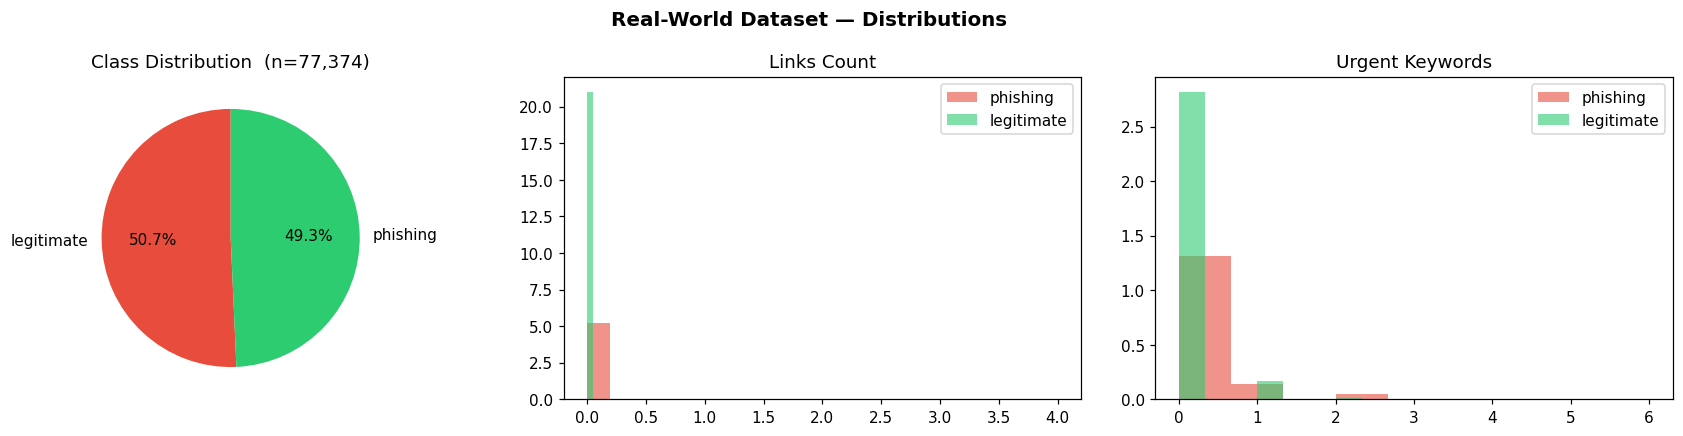

Class counts: phishing=38,139  legitimate=39,235


In [26]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8 — Dataset preview & distribution plots
# ════════════════════════════════════════════════════════════════════════════
print('=== CLEANED DATASET PREVIEW ===')
display(df[['label','subject','email_text','sender_domain',
            'has_attachment','links_count','urgent_keywords']].head(8))

print('\n=== FEATURE STATISTICS ===')
display(df[['links_count','urgent_keywords']].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Real-World Dataset — Distributions', fontsize=13, fontweight='bold')

counts = df['label'].value_counts().rename({1:'phishing', 0:'legitimate'})
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#e74c3c','#2ecc71'], startangle=90)
axes[0].set_title(f'Class Distribution  (n={len(df):,})')

for lbl, col, num in [('phishing','#e74c3c',1), ('legitimate','#2ecc71',0)]:
    axes[1].hist(df.loc[df['label']==num,'links_count'].clip(upper=20),
                 bins=21, alpha=0.6, color=col, label=lbl, density=True)
axes[1].set_title('Links Count'); axes[1].legend()

for lbl, col, num in [('phishing','#e74c3c',1), ('legitimate','#2ecc71',0)]:
    axes[2].hist(df.loc[df['label']==num,'urgent_keywords'].clip(upper=8),
                 bins=9, alpha=0.6, color=col, label=lbl, density=True)
axes[2].set_title('Urgent Keywords'); axes[2].legend()

plt.tight_layout(); plt.show()
print(f'Class counts: phishing={int((df["label"]==1).sum()):,}  '
      f'legitimate={int((df["label"]==0).sum()):,}')

---
## STEP 5 — Feature Engineering

In [27]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9 — extract_additional_features() — EXACT COPY of train.py
# ════════════════════════════════════════════════════════════════════════════
def extract_additional_features(df):
    df = df.copy()

    df['email_length']   = df['email_text'].apply(lambda x: len(str(x)))
    df['subject_length'] = df['subject'].apply(lambda x: len(str(x)))
    df['link_density']   = df['links_count'] / (df['email_length'] + 1)

    df['legitimate_domain'] = df['sender_domain'].apply(
        lambda x: 1 if str(x).lower().strip() in LEGITIMATE_DOMAINS else 0)
    df['suspicious_tld'] = df['sender_domain'].apply(
        lambda x: 1 if any(str(x).lower().strip().endswith(t)
                           for t in SUSPICIOUS_TLDS) else 0)
    df['domain_length']     = df['sender_domain'].apply(lambda x: len(str(x)))
    df['domain_has_digits'] = df['sender_domain'].apply(
        lambda x: int(any(c.isdigit() for c in str(x))))
    df['domain_has_hyphen'] = df['sender_domain'].apply(
        lambda x: int('-' in str(x)))
    df['domain_age'] = df['sender_domain'].apply(
        lambda x: 30 if str(x).lower().strip() in LEGITIMATE_DOMAINS
        else max(1, abs(hash(str(x))) % 8 + 1))

    def count_ip_urls(text):
        return len(re.findall(
            r'https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}',
            str(text).lower()))
    def count_shorteners(text):
        t = str(text).lower()
        return sum(1 for s in URL_SHORTENERS if s in t)
    def count_https(text):
        return len(re.findall(r'https://', str(text).lower()))
    def count_http(text):
        return len(re.findall(r'http://', str(text).lower()))

    df['ip_url_count']        = df['email_text'].apply(count_ip_urls)
    df['shortener_url_count'] = df['email_text'].apply(count_shorteners)
    df['https_url_count']     = df['email_text'].apply(count_https)
    df['http_url_count']      = df['email_text'].apply(count_http)
    df['http_ratio']          = df['http_url_count'] / (df['links_count'] + 1)

    df['special_chars'] = df['email_text'].apply(
        lambda x: len(re.findall(r"[!$%^&*()_+|~=`{}\[\]:"+'\"'+r"'<>?,./]", str(x))))
    df['html_tags'] = df['email_text'].apply(
        lambda x: len(re.findall(r'<[^>]+>', str(x).lower())))

    return df

df = extract_additional_features(df)
print(f'✓ Feature engineering done. Total columns: {len(df.columns)}')
display(df[NUMERIC_FEATURES].describe().round(3))

✓ Feature engineering done. Total columns: 23


,has_attachment,links_count,urgent_keywords,email_length,subject_length,link_density,domain_age,special_chars,html_tags,legitimate_domain,suspicious_tld,ip_url_count,shortener_url_count,https_url_count,http_url_count,http_ratio,domain_length,domain_has_digits,domain_has_hyphen
count,77374.00,77374.000,77374.000,77374.000,77374.000,77374.000,77374.000,77374.000,77374.0,77374.000,77374.000,77374.0,77374.000,77374.000,77374.000,77374.000,77374.000,77374.000,77374.000
mean,0.00,0.000,0.109,1611.892,36.987,0.000,4.561,86.028,0.0,0.061,0.005,0.0,0.028,0.000,0.000,0.000,7.218,0.023,0.034
std,0.01,0.029,0.364,17236.983,34.991,0.001,6.886,1028.947,0.0,0.239,0.069,0.0,0.169,0.012,0.028,0.028,7.099,0.149,0.182
min,0.00,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.0,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.00,0.000,0.000,292.000,23.000,0.000,1.000,8.000,0.0,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.00,0.000,0.000,666.500,34.000,0.000,2.000,28.000,0.0,0.000,0.000,0.0,0.000,0.000,0.000,0.000,8.000,0.000,0.000
75%,0.00,0.000,0.000,1636.000,47.000,0.000,5.000,79.000,0.0,0.000,0.000,0.0,0.000,0.000,0.000,0.000,12.000,0.000,0.000
max,1.00,4.000,6.000,4545977.000,7169.000,0.111,30.000,192880.000,0.0,1.000,1.000,0.0,4.000,3.000,5.000,5.000,57.000,1.000,1.000


---
## STEP 6 — Train/Test Split & Preprocessor *(identical to train.py)*

In [28]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 10 — Split & build preprocessor (exact copy of train.py)
# ════════════════════════════════════════════════════════════════════════════
X = df.drop('label', axis=1)
y = df['label']

n_phish = int(y.sum())
n_legit = int((y == 0).sum())
print(f'Rows: {len(df):,}  |  Phishing: {n_phish:,}  |  Legitimate: {n_legit:,}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Sample weights — same formula as train.py
w_phish = 1.0
w_legit = (n_phish / n_legit) * 1.4
sw_train = np.where(y_train == 1, w_phish, w_legit)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'w_phish={w_phish:.3f}  w_legit={w_legit:.4f}')

# build_preprocessor() — EXACT copy of train.py
def build_preprocessor():
    text_vec = Pipeline([
        ('hash', HashingVectorizer(
            n_features=2**16, alternate_sign=False,
            stop_words='english', ngram_range=(1, 2)))
    ])
    domain_vec = Pipeline([
        ('hash', HashingVectorizer(n_features=512, alternate_sign=False))
    ])
    return ColumnTransformer(transformers=[
        ('email_text',   text_vec,   'email_text'),
        ('subject',      text_vec,   'subject'),
        ('sender_domain',domain_vec, 'sender_domain'),
        ('num',          StandardScaler(), NUMERIC_FEATURES),
    ])

print('\n✓ Preprocessor built')

Rows: 77,374  |  Phishing: 38,139  |  Legitimate: 39,235
Train: 61,899  |  Test: 15,475
w_phish=1.000  w_legit=1.3609

✓ Preprocessor built


---
## STEP 7 — Model Catalogue *(identical to train.py)*

In [29]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 11 — get_model_catalogue() — EXACT COPY of train.py
# ════════════════════════════════════════════════════════════════════════════
def get_model_catalogue():
    catalogue = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, C=1.0, class_weight='balanced', random_state=42),
        'Random Forest': RandomForestClassifier(
            n_estimators=150, max_depth=12, min_samples_leaf=4,
            class_weight='balanced', random_state=42, n_jobs=-1),
        'Extra Trees': ExtraTreesClassifier(
            n_estimators=150, max_depth=12, min_samples_leaf=4,
            class_weight='balanced', random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.08, max_depth=5,
            subsample=0.8, max_features='sqrt', min_samples_leaf=4,
            random_state=42),
    }
    try:
        from xgboost import XGBClassifier
        catalogue['XGBoost'] = XGBClassifier(
            n_estimators=200, learning_rate=0.08, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', random_state=42,
            use_label_encoder=False, n_jobs=-1)
        print('  XGBoost available ✓')
    except ImportError:
        print('  XGBoost not installed — skipping')
    return catalogue

catalogue = get_model_catalogue()
print(f'Models to train: {list(catalogue.keys())}')

  XGBoost available ✓
Models to train: ['Logistic Regression', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost']


---
## STEP 8 — Train All Models & Evaluate

In [30]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 12 — Train all models (same loop as train.py)
# ════════════════════════════════════════════════════════════════════════════
results   = {}
pipelines = {}

hdr = f"{'Model':<22} {'AUC':>6} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1@0.5':>8} {'F1@0.60':>8} {'FP':>6} {'FN':>6}"
print(hdr)
print('─' * len(hdr))

for name, clf in catalogue.items():
    pipe = Pipeline([
        ('preprocessor', build_preprocessor()),
        ('classifier',   clf),
    ])

    fit_params = {}
    if name in ('Gradient Boosting', 'XGBoost'):
        fit_params['classifier__sample_weight'] = sw_train

    pipe.fit(X_train, y_train, **fit_params)

    y_proba   = pipe.predict_proba(X_test)[:, 1]
    y_pred_50 = pipe.predict(X_test)
    y_pred_th = (y_proba >= THRESHOLD).astype(int)

    auc   = roc_auc_score(y_test, y_proba)
    acc   = accuracy_score(y_test, y_pred_th)
    prec  = precision_score(y_test, y_pred_th, zero_division=0)
    rec   = recall_score(y_test, y_pred_th, zero_division=0)
    f1_50 = f1_score(y_test, y_pred_50, zero_division=0)
    f1_th = f1_score(y_test, y_pred_th, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()

    results[name] = {
        'auc': round(float(auc), 4),
        'accuracy': round(float(acc), 4),
        'precision': round(float(prec), 4),
        'recall': round(float(rec), 4),
        'f1_at_50': round(float(f1_50), 4),
        f'f1_at_{THRESHOLD}': round(float(f1_th), 4),
        f'fp_at_{THRESHOLD}': int(fp),
        f'fn_at_{THRESHOLD}': int(fn),
        'tn': int(tn), 'tp': int(tp),
    }
    pipelines[name] = pipe

    print(f'{name:<22} {auc:>6.4f} {acc:>6.4f} {prec:>6.4f} '
          f'{rec:>6.4f} {f1_50:>8.4f} {f1_th:>8.4f} {fp:>6d} {fn:>6d}')

best_name = max(results, key=lambda n: results[n][f'f1_at_{THRESHOLD}'])
print(f'\n★ Best model: {best_name}  '
      f'(F1@{THRESHOLD} = {results[best_name][f"f1_at_{THRESHOLD}"]:.4f})')

Model                     AUC    Acc   Prec    Rec   F1@0.5  F1@0.60     FP     FN
──────────────────────────────────────────────────────────────────────────────────
Logistic Regression    0.9990 0.9850 0.9880 0.9815   0.9851   0.9847     91    141
Random Forest          0.9733 0.7002 0.9993 0.3920   0.8943   0.5631      2   4638
Extra Trees            0.9875 0.5531 0.9958 0.0937   0.9411   0.1713      3   6913
Gradient Boosting      0.9915 0.9230 0.9867 0.8554   0.9521   0.9164     88   1103
XGBoost                0.9948 0.9594 0.9680 0.9490   0.9635   0.9584    239    389

★ Best model: Logistic Regression  (F1@0.6 = 0.9847)


---
## STEP 9 — Per-Model Classification Reports

In [31]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 13 — Detailed classification reports
# ════════════════════════════════════════════════════════════════════════════
for name in pipelines:
    y_proba = pipelines[name].predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= THRESHOLD).astype(int)
    print(f'\n{"="*55}')
    print(f'  {name}  (threshold={THRESHOLD})')
    print('='*55)
    print(classification_report(y_test, y_pred,
                                 target_names=['legitimate','phishing']))


  Logistic Regression  (threshold=0.6)
              precision    recall  f1-score   support

  legitimate       0.98      0.99      0.99      7847
    phishing       0.99      0.98      0.98      7628

    accuracy                           0.99     15475
   macro avg       0.99      0.98      0.99     15475
weighted avg       0.99      0.99      0.99     15475


  Random Forest  (threshold=0.6)
              precision    recall  f1-score   support

  legitimate       0.63      1.00      0.77      7847
    phishing       1.00      0.39      0.56      7628

    accuracy                           0.70     15475
   macro avg       0.81      0.70      0.67     15475
weighted avg       0.81      0.70      0.67     15475


  Extra Trees  (threshold=0.6)
              precision    recall  f1-score   support

  legitimate       0.53      1.00      0.69      7847
    phishing       1.00      0.09      0.17      7628

    accuracy                           0.55     15475
   macro avg       0.7

---
## STEP 10 — Confusion Matrices

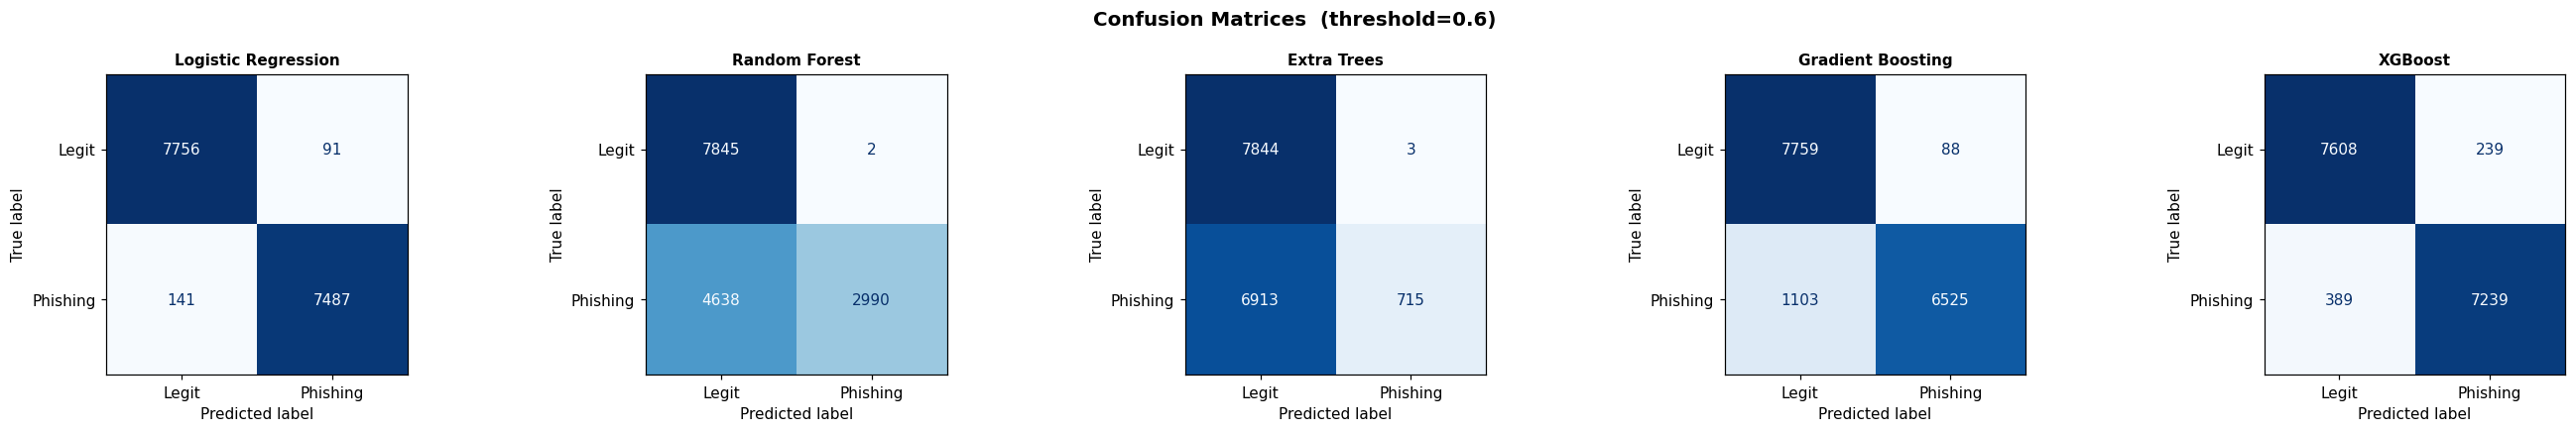

In [32]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 14 — Confusion matrix for every model
# ════════════════════════════════════════════════════════════════════════════
n_m = len(pipelines)
fig, axes = plt.subplots(1, n_m, figsize=(5*n_m, 4))
if n_m == 1: axes = [axes]
fig.suptitle(f'Confusion Matrices  (threshold={THRESHOLD})',
             fontsize=13, fontweight='bold')

for ax, name in zip(axes, pipelines):
    yp  = pipelines[name].predict_proba(X_test)[:, 1]
    yh  = (yp >= THRESHOLD).astype(int)
    cm  = confusion_matrix(y_test, yh)
    ConfusionMatrixDisplay(cm, display_labels=['Legit','Phishing']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')

plt.tight_layout(); plt.show()

---
## STEP 11 — Model Performance Comparison Charts

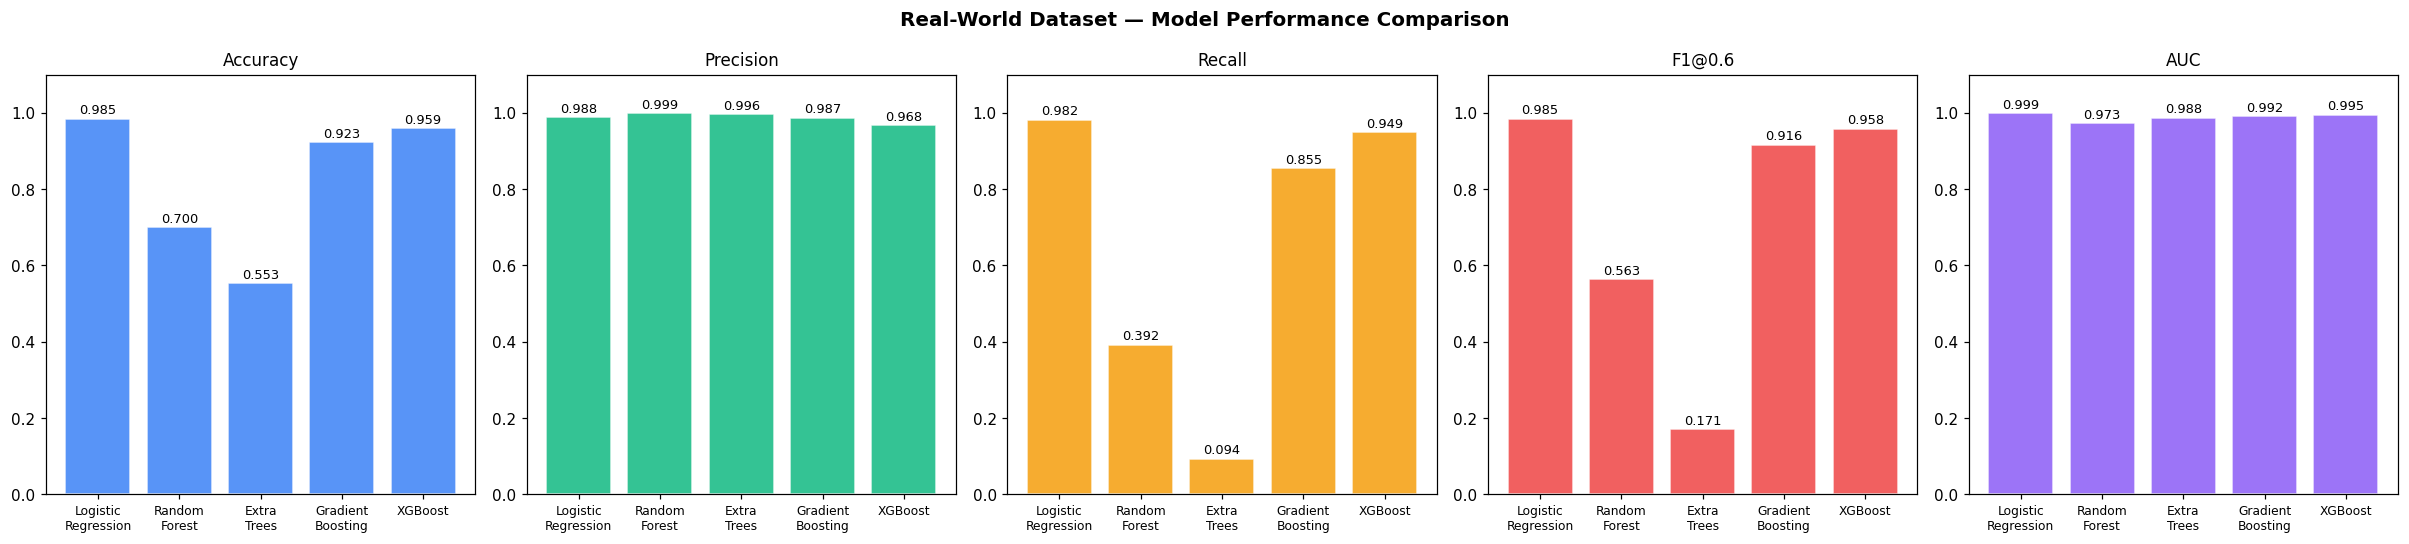

In [33]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 15 — Bar charts (Accuracy / Precision / Recall / F1 / AUC)
# ════════════════════════════════════════════════════════════════════════════
model_names  = list(results.keys())
short_names  = [n.replace(' ', '\n') for n in model_names]
met_keys  = ['accuracy','precision','recall',f'f1_at_{THRESHOLD}','auc']
met_labels= ['Accuracy','Precision','Recall',f'F1@{THRESHOLD}','AUC']
colors    = ['#3B82F6','#10B981','#F59E0B','#EF4444','#8B5CF6']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Real-World Dataset — Model Performance Comparison',
             fontsize=13, fontweight='bold')

for ax, key, label, color in zip(axes, met_keys, met_labels, colors):
    vals = [results[n][key] for n in model_names]
    bars = ax.bar(short_names, vals, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5)
    ax.set_ylim(0, 1.10)
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout(); plt.show()

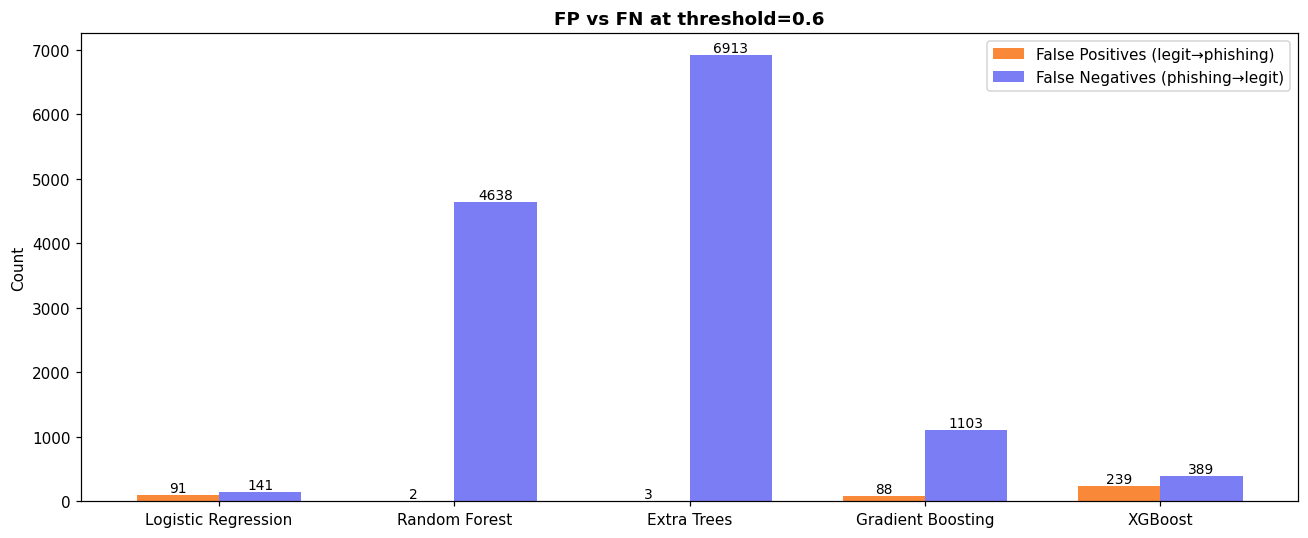

In [34]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 16 — FP vs FN comparison
# ════════════════════════════════════════════════════════════════════════════
fp_vals = [results[n][f'fp_at_{THRESHOLD}'] for n in model_names]
fn_vals = [results[n][f'fn_at_{THRESHOLD}'] for n in model_names]
x = np.arange(len(model_names)); w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x-w/2, fp_vals, w, label='False Positives (legit→phishing)',
            color='#F97316', alpha=0.85)
b2 = ax.bar(x+w/2, fn_vals, w, label='False Negatives (phishing→legit)',
            color='#6366F1', alpha=0.85)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_title(f'FP vs FN at threshold={THRESHOLD}', fontsize=12, fontweight='bold')
ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()

---
## STEP 12 — ROC & Precision-Recall Curves

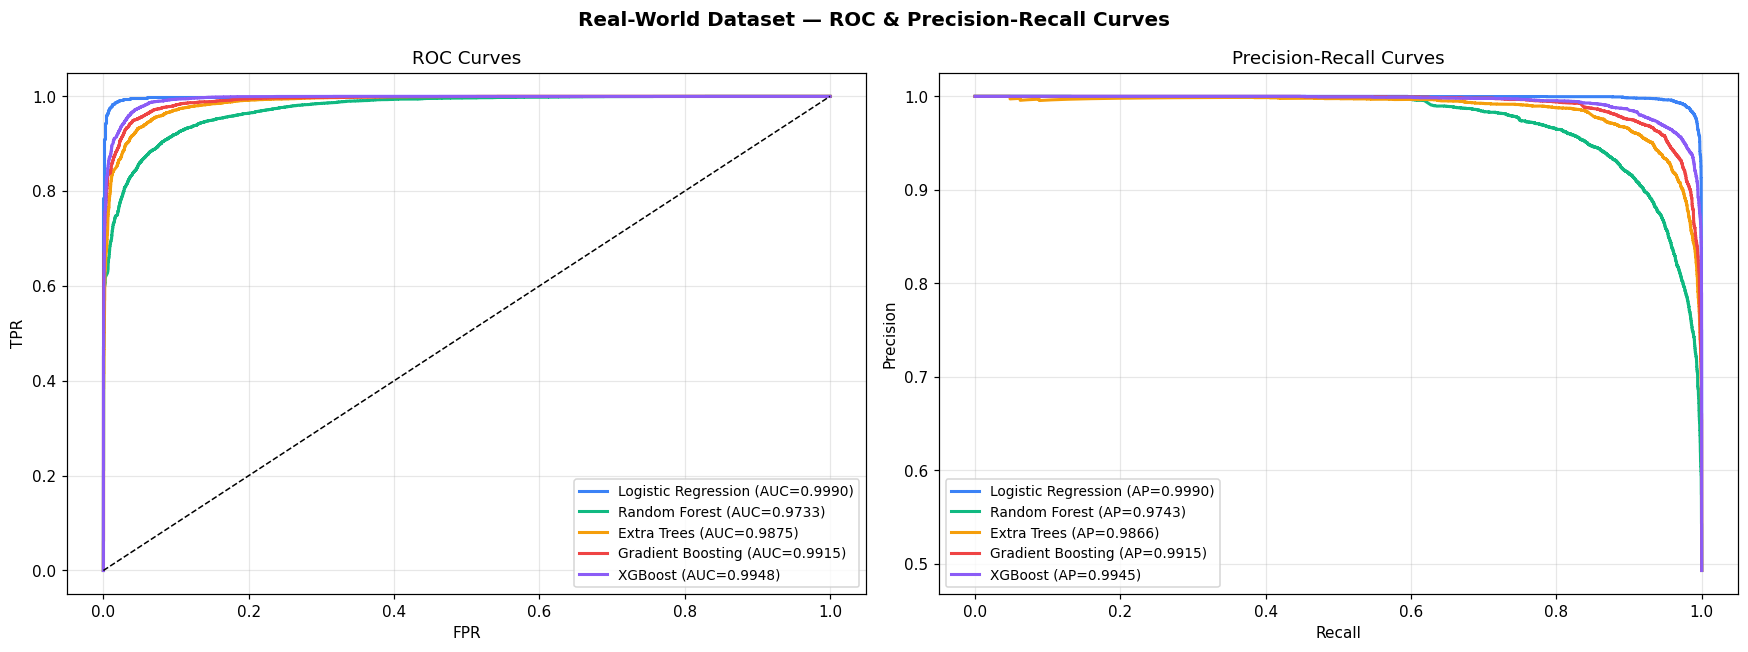

In [35]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 17 — ROC & PR curves
# ════════════════════════════════════════════════════════════════════════════
roc_colors = ['#3B82F6','#10B981','#F59E0B','#EF4444','#8B5CF6']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Real-World Dataset — ROC & Precision-Recall Curves',
             fontsize=13, fontweight='bold')

for (name, pipe), color in zip(pipelines.items(), roc_colors):
    yp = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC={results[name]["auc"]:.4f})')
    pc, rc, _ = precision_recall_curve(y_test, yp)
    ap = average_precision_score(y_test, yp)
    ax2.plot(rc, pc, color=color, lw=2,
             label=f'{name} (AP={ap:.4f})')

ax1.plot([0,1],[0,1],'k--',lw=1)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curves'); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## STEP 13 — Final Summary Table

In [36]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 18 — Final comparison table
# ════════════════════════════════════════════════════════════════════════════
rows = []
for name in model_names:
    r = results[name]
    rows.append({
        'Model'           : name,
        'AUC'             : r['auc'],
        'Accuracy'        : r['accuracy'],
        'Precision'       : r['precision'],
        'Recall'          : r['recall'],
        f'F1@{THRESHOLD}' : r[f'f1_at_{THRESHOLD}'],
        'FP'              : r[f'fp_at_{THRESHOLD}'],
        'FN'              : r[f'fn_at_{THRESHOLD}'],
        'Best?'           : '★' if name == best_name else '',
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print('=== FINAL MODEL COMPARISON — REAL-WORLD DATASET ===\n')
display(summary_df.style
        .highlight_max(subset=['AUC','Accuracy','Precision',
                               'Recall',f'F1@{THRESHOLD}'],
                       color='#d4edda')
        .format(precision=4))

=== FINAL MODEL COMPARISON — REAL-WORLD DATASET ===



,AUC,Accuracy,Precision,Recall,F1@0.6,FP,FN,Best?
Model,,,,,,,,
Logistic Regression,0.9990,0.9850,0.9880,0.9815,0.9847,91,141,★
Random Forest,0.9733,0.7002,0.9993,0.3920,0.5631,2,4638,
Extra Trees,0.9875,0.5531,0.9958,0.0937,0.1713,3,6913,
Gradient Boosting,0.9915,0.9230,0.9867,0.8554,0.9164,88,1103,
XGBoost,0.9948,0.9594,0.9680,0.9490,0.9584,239,389,


---
## STEP 14 — Save Best Model to Drive

In [37]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 20 — Save best model (.pkl) to Runtime + Optional Drive
# ════════════════════════════════════════════════════════════════════════════
import os
import joblib

# ── Runtime path (always works) ─────────────────────────────────────────────
runtime_save_path = '/content/phishing_detection.pkl'

meta = {
    'model_name' : best_name,
    'threshold'  : THRESHOLD,
    'f1'         : results[best_name][f'f1_at_{THRESHOLD}'],
    'auc'        : results[best_name]['auc'],
    'dataset'    : 'real-world (Enron + Ling + Nazario + Nigerian_Fraud + SpamAssasin)',
    'total_rows' : len(df),
    'results_all': results,
}

# Save in runtime
joblib.dump({'pipeline': pipelines[best_name], 'meta': meta}, runtime_save_path, compress=3)
print(f'✓ Model saved in runtime → {runtime_save_path}')

# ── Summary ────────────────────────────────────────────────────────────────
print(f"\nBest model : {best_name}")
print(f"F1@{THRESHOLD} : {meta['f1']:.4f}")
print(f"AUC           : {meta['auc']:.4f}")